
# Functional and Ecological Analysis of Amino Acid-Degrading Enzymes

This notebook implements a complete exploratory and ecological-functional analysis workflow
for amino acid-degrading enzyme production in halophilic and halotolerant bacteria isolated
from hypersaline environments of the Atacama Desert.

The workflow includes:

- Frequency and abundance analyses
- Relative prevalence estimation
- Functional richness analysis
- Heatmaps and clustered visualizations
- Functional enrichment analysis
- Co-occurrence analysis
- Correspondence Analysis (CA / MCA)
- Ecological-functional profiling
- Network analysis
- Advanced panel-ready visualizations

The objective is to explore how ecological adaptation, salinity tolerance,
taxonomy, and environment shape enzymatic synthesis landscapes.


In [26]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import seaborn as sns

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
from scipy.stats import fisher_exact

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import networkx as nx

try:
    import prince
    HAS_PRINCE = True
except:
    HAS_PRINCE = False

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11


## Load Dataset

In [27]:

df = pd.read_csv("../raw_data/requested_table.csv")

df["Site"] = df["Isolate"].apply(lambda x: "VL" if "VL" in x else "ST")

def classify_halophily(isolate):
    if "ST" in isolate:
        return "HE"
    elif isolate in ["VL 2","VL 10","VL 11","VL 12","VL 20","VL 21",
                      "VL 22","VL 23","VL 24","VL 25","VL 26",
                      "VL 27","VL 28","VL 29","VL 42"]:
        return "HM"
    else:
        return "HA"

df["Halophily"] = df["Isolate"].apply(classify_halophily)

enzyme_cols = ["ASNase","GLNase","SDH","GO","ADI","MGL"]

df.head()


,Isolate,ASNase,GLNase,SDH,GO,ADI,MGL,Site,Halophily
0,VL 1,1,0,0,0,1,0,VL,HA
1,VL 2,1,1,1,1,1,0,VL,HM
2,VL 3,1,1,0,0,1,0,VL,HA
3,VL 4,1,1,0,0,1,0,VL,HA
4,VL 5,1,1,0,0,1,0,VL,HA


## 1. Global Enzyme Frequency

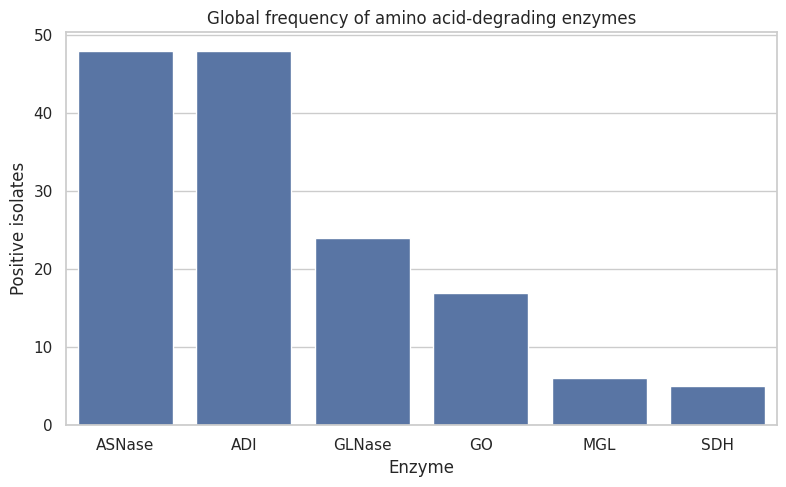

In [28]:

freq = df[enzyme_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=freq.index, y=freq.values)

plt.ylabel("Positive isolates")
plt.xlabel("Enzyme")
plt.title("Global frequency of amino acid-degrading enzymes")

plt.tight_layout()
plt.show()


## 2. Relative Abundance by Halophily

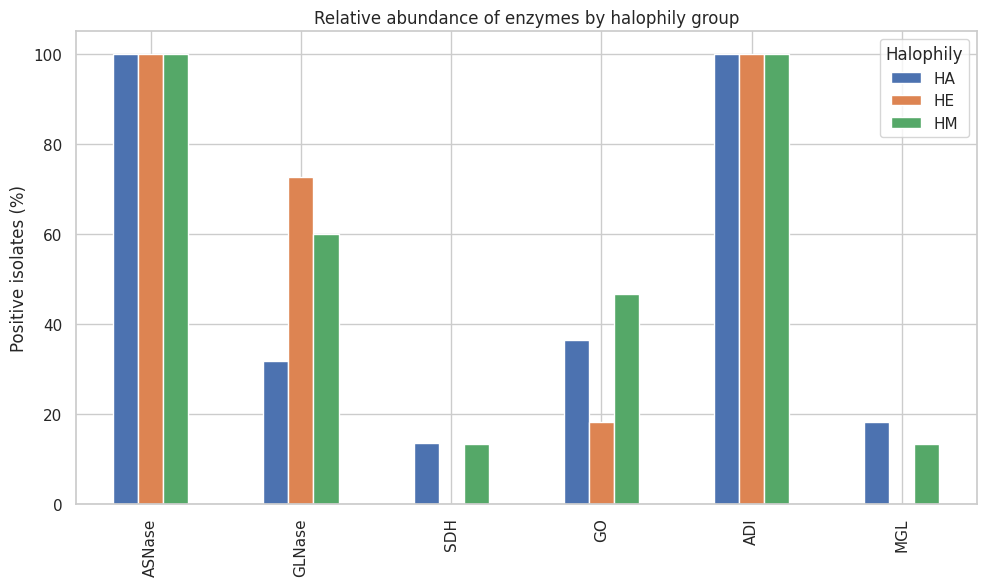

In [29]:

abundance = (
    df.groupby("Halophily")[enzyme_cols]
    .mean()
    .T
    * 100
)

abundance.plot(kind="bar", figsize=(10,6))

plt.ylabel("Positive isolates (%)")
plt.title("Relative abundance of enzymes by halophily group")

plt.tight_layout()
plt.show()


## 3. Relative Abundance by Site

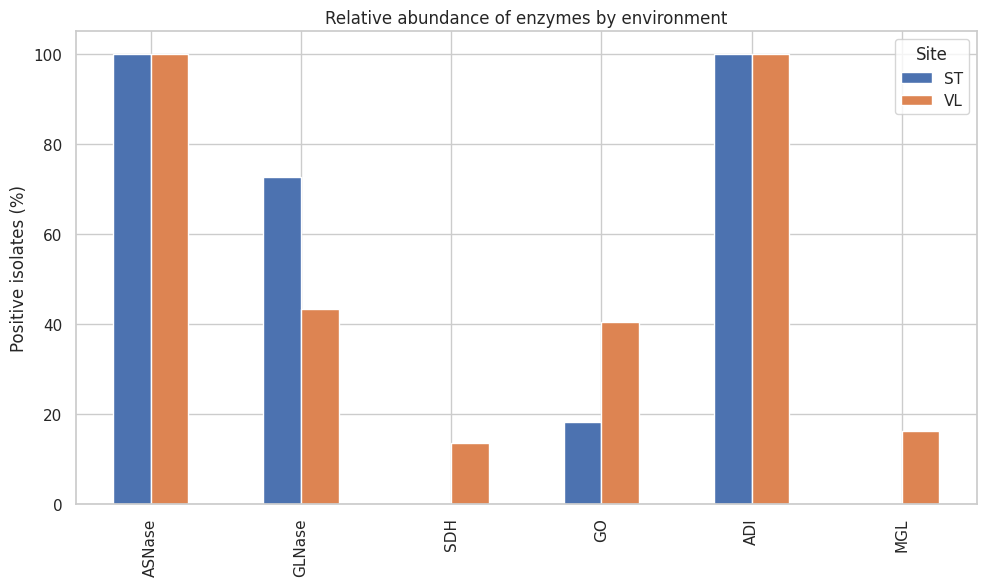

In [30]:

site_abundance = (
    df.groupby("Site")[enzyme_cols]
    .mean()
    .T
    * 100
)

site_abundance.plot(kind="bar", figsize=(10,6))

plt.ylabel("Positive isolates (%)")
plt.title("Relative abundance of enzymes by environment")

plt.tight_layout()
plt.show()


## 4. Functional Richness Analysis

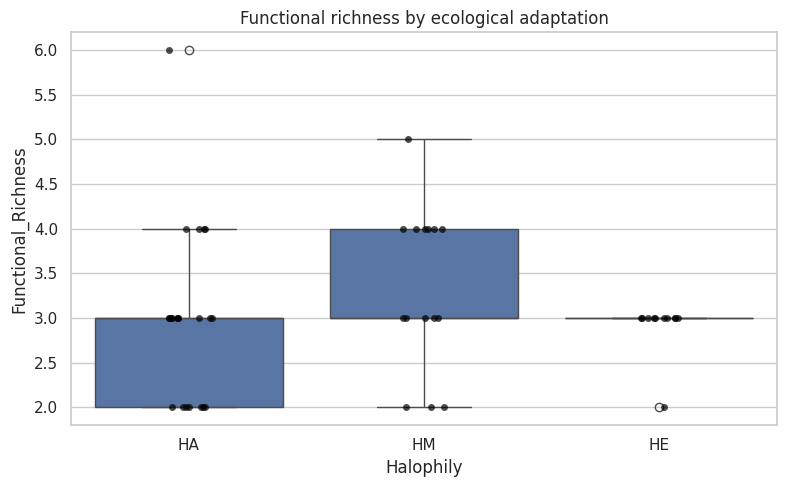

In [31]:

df["Functional_Richness"] = df[enzyme_cols].sum(axis=1)

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Halophily",
    y="Functional_Richness"
)

sns.stripplot(
    data=df,
    x="Halophily",
    y="Functional_Richness",
    color="black",
    alpha=0.7
)

plt.title("Functional richness by ecological adaptation")

plt.tight_layout()
plt.show()


## 5. Functional Heatmap

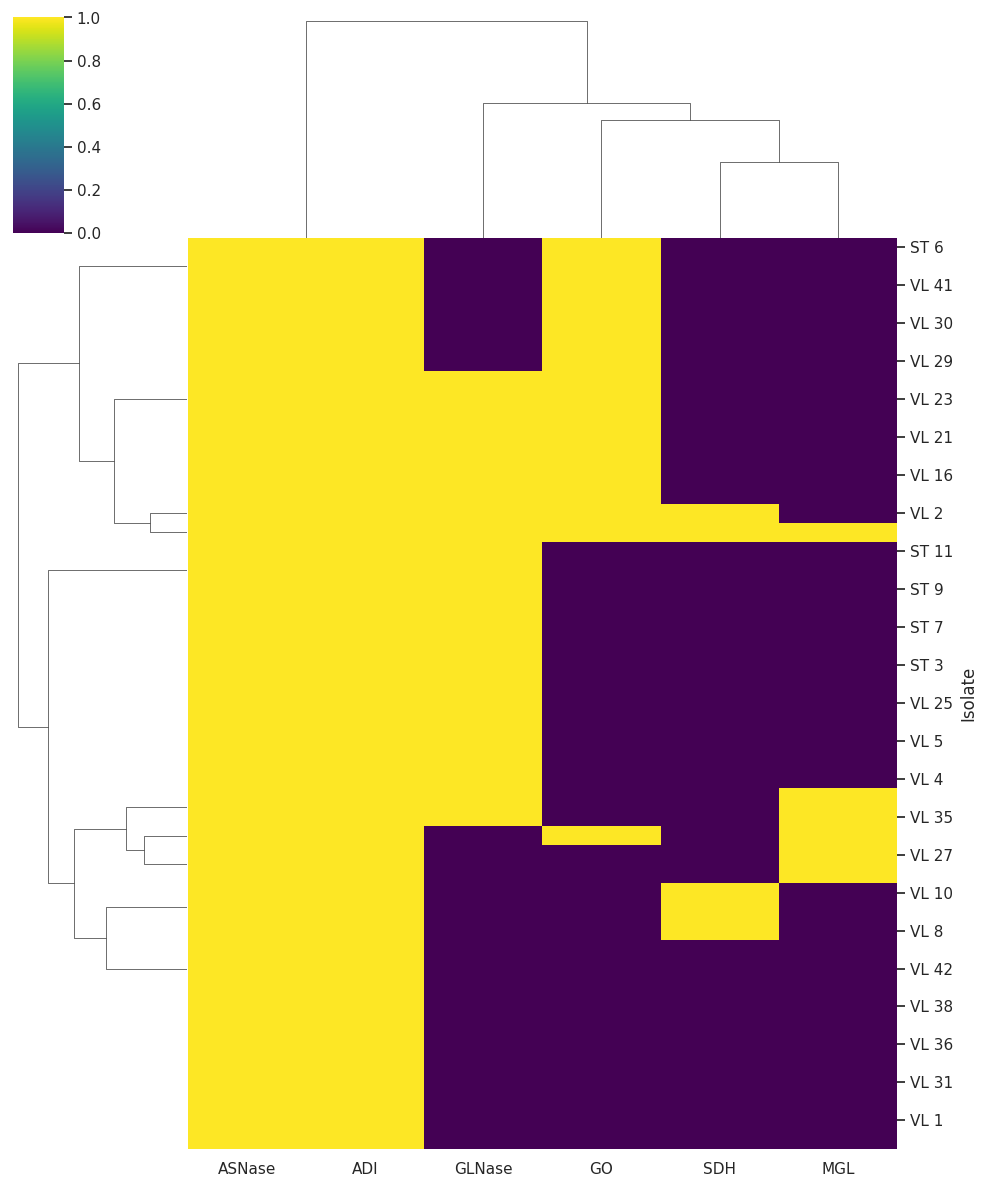

In [32]:

heatmap_df = df.set_index("Isolate")[enzyme_cols]

sns.clustermap(
    heatmap_df,
    cmap="viridis",
    figsize=(10,12),
    metric="euclidean",
    method="ward"
)

plt.show()


## 6. Functional Enrichment Heatmap

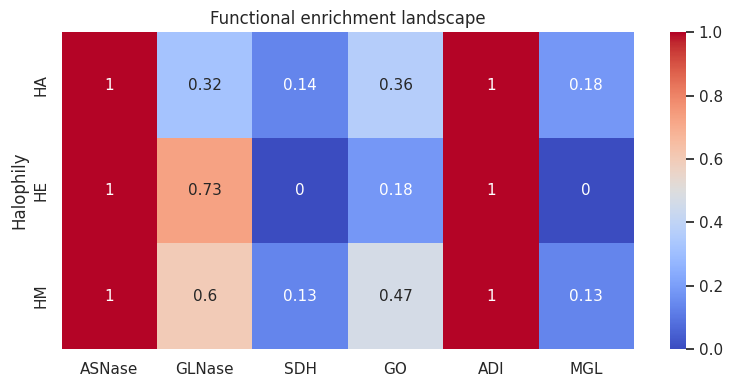

In [33]:

enrich = (
    df.groupby("Halophily")[enzyme_cols]
    .mean()
)

plt.figure(figsize=(8,4))

sns.heatmap(
    enrich,
    annot=True,
    cmap="coolwarm",
    vmin=0,
    vmax=1
)

plt.title("Functional enrichment landscape")

plt.tight_layout()
plt.show()


## 7. Enzyme Co-occurrence Matrix

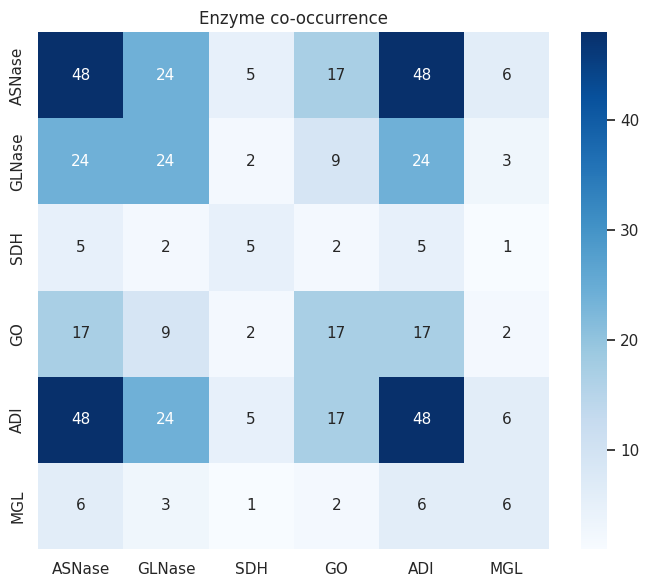

In [34]:

cooccur = pd.DataFrame(index=enzyme_cols, columns=enzyme_cols)

for i in enzyme_cols:
    for j in enzyme_cols:
        cooccur.loc[i, j] = np.sum(
            (df[i] == 1) & (df[j] == 1)
        )

cooccur = cooccur.astype(int)

plt.figure(figsize=(7,6))

sns.heatmap(
    cooccur,
    annot=True,
    cmap="Blues"
)

plt.title("Enzyme co-occurrence")

plt.tight_layout()
plt.show()


## 8. PCA Functional Landscape

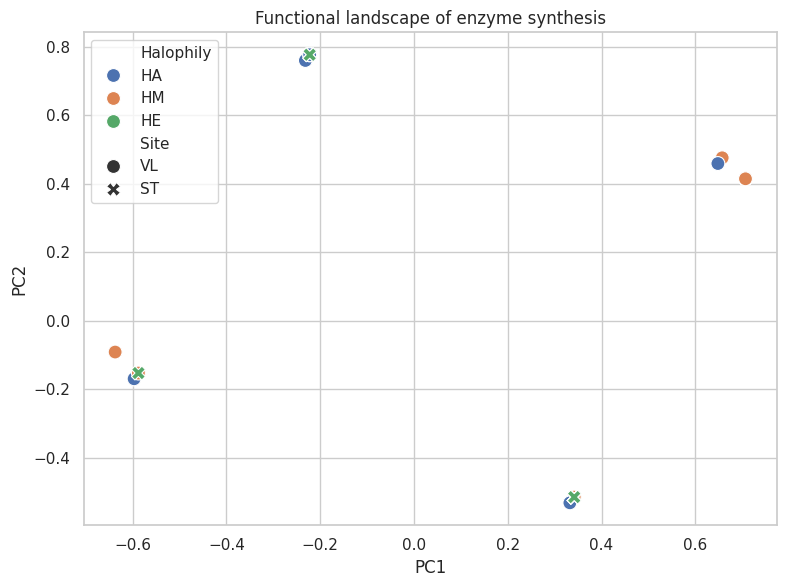

In [35]:

X = df[enzyme_cols].values

pca = PCA(n_components=2)

coords = pca.fit_transform(X)

pca_df = pd.DataFrame({
    "PC1": coords[:,0],
    "PC2": coords[:,1],
    "Halophily": df["Halophily"],
    "Site": df["Site"]
})

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Halophily",
    style="Site",
    s=100
)

plt.title("Functional landscape of enzyme synthesis")

plt.tight_layout()
plt.show()


## 9. Correspondence Analysis (Optional)

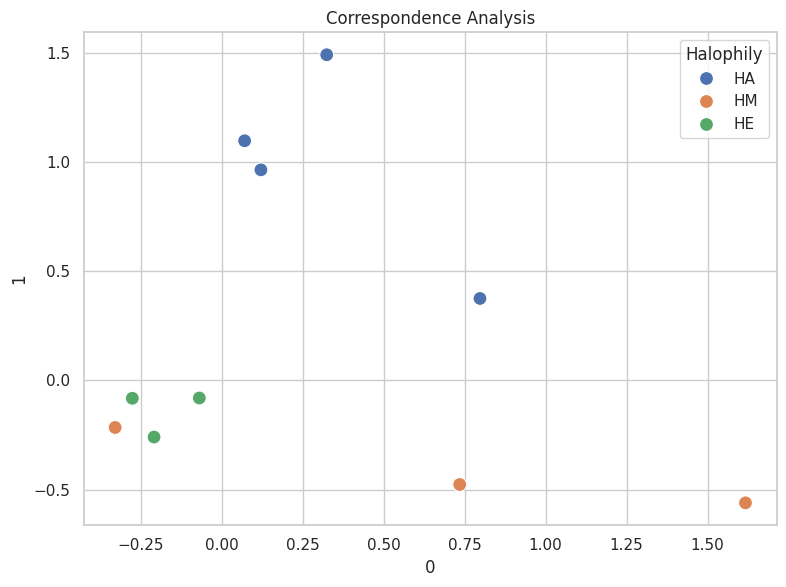

In [36]:

if HAS_PRINCE:

    ca = prince.CA(n_components=2)

    ca_fit = ca.fit(df[enzyme_cols])

    coords = ca.row_coordinates(df[enzyme_cols])

    coords["Halophily"] = df["Halophily"].values

    plt.figure(figsize=(8,6))

    sns.scatterplot(
        data=coords,
        x=0,
        y=1,
        hue="Halophily",
        s=100
    )

    plt.title("Correspondence Analysis")

    plt.tight_layout()
    plt.show()

else:
    print("Install prince package for CA/MCA analysis.")


## 10. Bipartite Functional Network

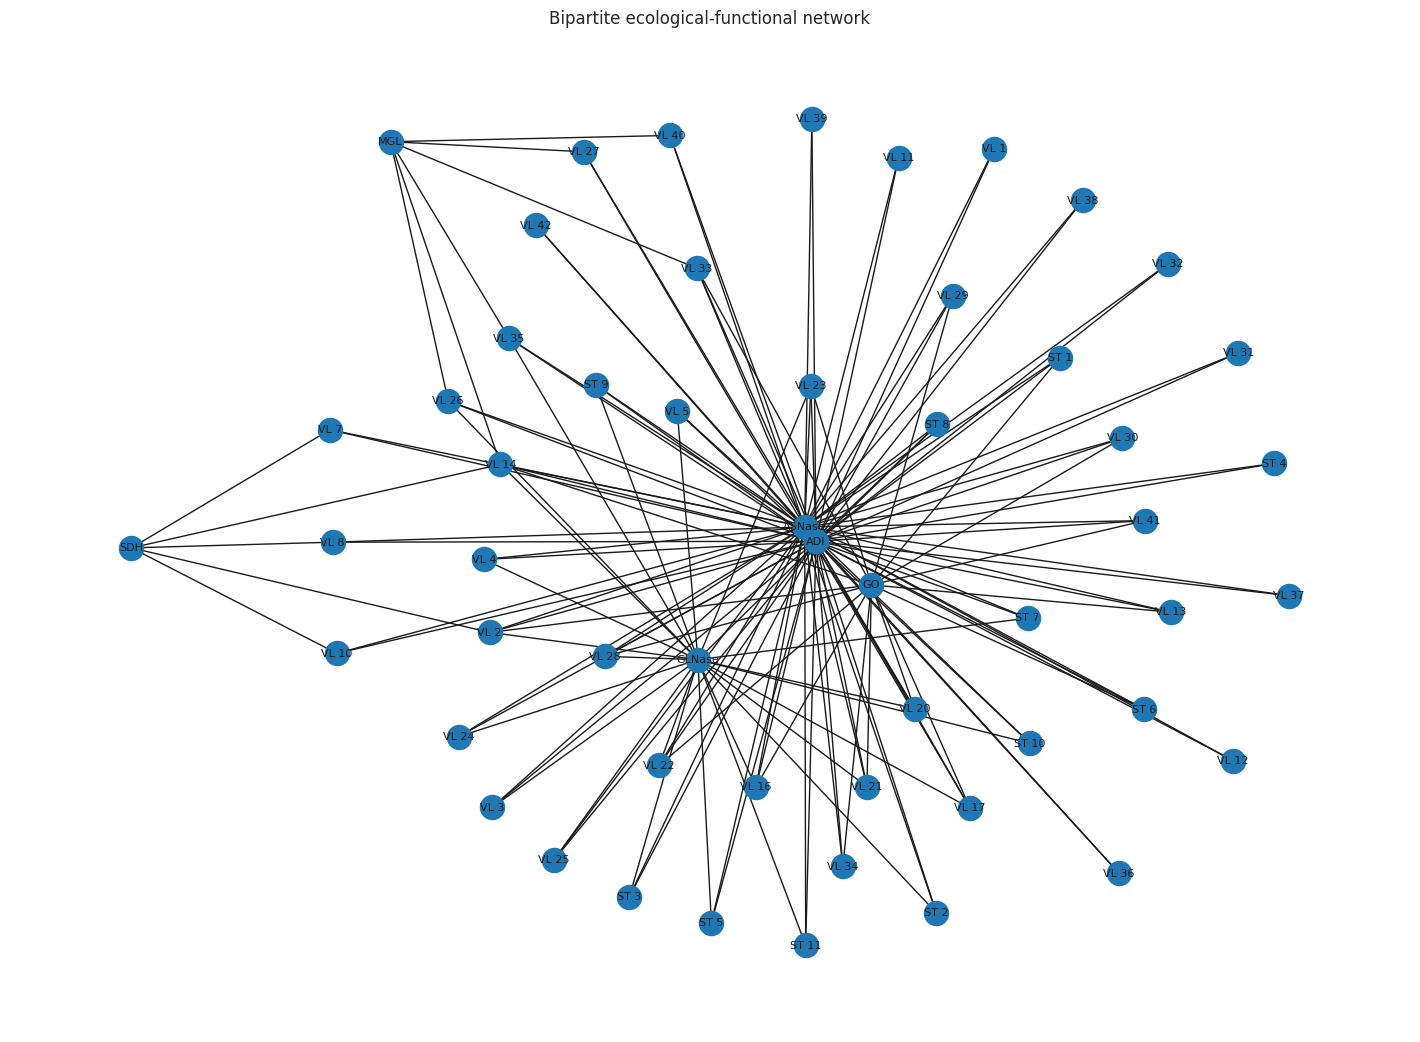

In [37]:

G = nx.Graph()

isolates = df["Isolate"].tolist()

G.add_nodes_from(isolates, bipartite=0)
G.add_nodes_from(enzyme_cols, bipartite=1)

for _, row in df.iterrows():
    for enzyme in enzyme_cols:
        if row[enzyme] == 1:
            G.add_edge(row["Isolate"], enzyme)

plt.figure(figsize=(14,10))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=300,
    font_size=8
)

plt.title("Bipartite ecological-functional network")

plt.show()


## 11. Rare Enzyme Analysis

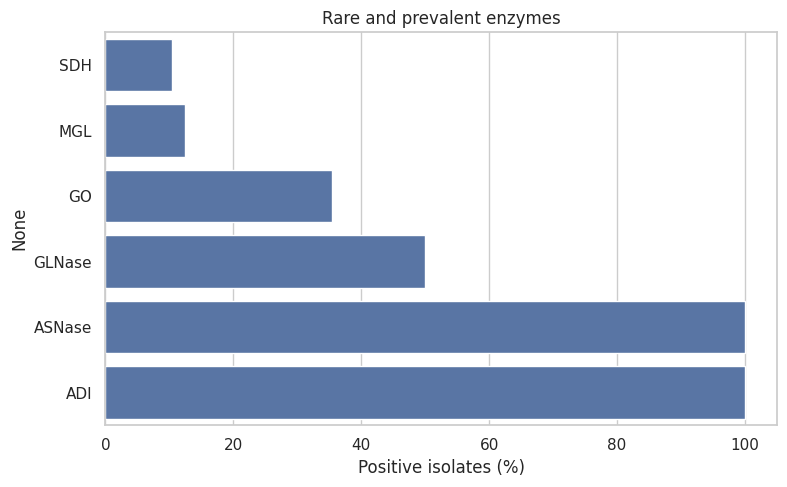

In [38]:

rare = freq / len(df) * 100

rare = rare.sort_values()

plt.figure(figsize=(8,5))

sns.barplot(
    x=rare.values,
    y=rare.index
)

plt.xlabel("Positive isolates (%)")
plt.title("Rare and prevalent enzymes")

plt.tight_layout()
plt.show()


## 12. Multi-panel Figure Prototype

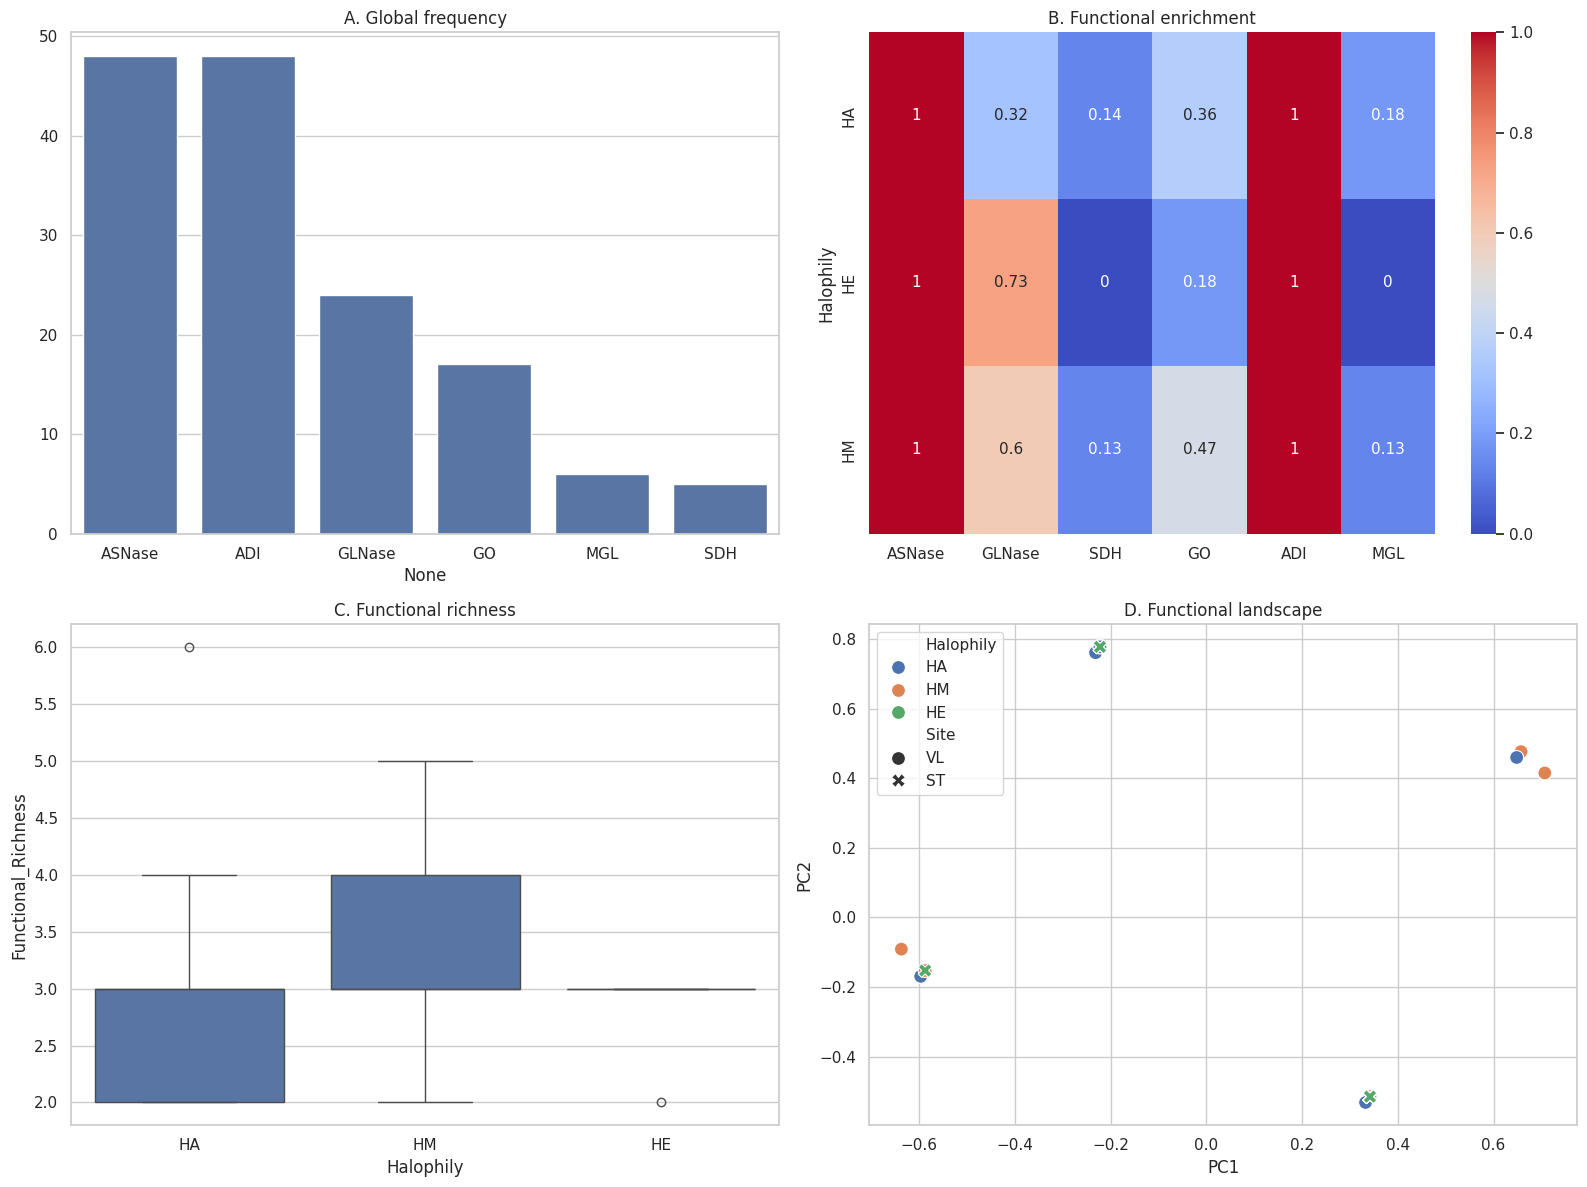

In [39]:

fig = plt.figure(figsize=(16,12))

gs = gridspec.GridSpec(2, 2, figure=fig)

ax1 = fig.add_subplot(gs[0,0])
sns.barplot(
    x=freq.index,
    y=freq.values,
    ax=ax1
)
ax1.set_title("A. Global frequency")

ax2 = fig.add_subplot(gs[0,1])
sns.heatmap(
    enrich,
    cmap="coolwarm",
    annot=True,
    ax=ax2
)
ax2.set_title("B. Functional enrichment")

ax3 = fig.add_subplot(gs[1,0])
sns.boxplot(
    data=df,
    x="Halophily",
    y="Functional_Richness",
    ax=ax3
)
ax3.set_title("C. Functional richness")

ax4 = fig.add_subplot(gs[1,1])
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Halophily",
    style="Site",
    s=100,
    ax=ax4
)
ax4.set_title("D. Functional landscape")

plt.tight_layout()
plt.show()
